# Topics in Quantitative Finance - Homework 4

Assigned: August 4, 2026.
Due: Thursday, **August 6, 2026 by 1PM**. 

Late homework **will not be accepted**.

$$
\newcommand{\supp}{\mathrm{supp}}
\newcommand{\E}{\mathbb{E} }
\newcommand{\Eof}[1]{\mathbb{E}\left[ #1 \right]}
\def\Cov{{ \mbox{Cov} }}
\def\Var{{ \mbox{Var} }}
\newcommand{\1}{\mathbf{1} }
\newcommand{\PP}{\mathbb{P} }
\newcommand{\Pof}[1]{\mathbb{P}\left[ #1 \right]}
%\newcommand{\Pr}{\mathrm{Pr} }
\newcommand{\QQ}{\mathbb{Q} }
\newcommand{\RR}{\mathbb{R} }
\newcommand{\DD}{\mathbb{D} }
\newcommand{\HH}{\mathbb{H} }
\newcommand{\spn}{\mathrm{span} }
\newcommand{\cov}{\mathrm{cov} }
\newcommand{\sgn}{\mathrm{sgn} }
\newcommand{\HS}{\mathcal{L}_{\mathrm{HS}} }
%\newcommand{\HS}{\mathrm{HS} }
\newcommand{\trace}{\mathrm{trace} }
\newcommand{\LL}{\mathcal{L} }
%\newcommand{\LL}{\mathrm{L} }
\newcommand{\s}{\mathcal{S} }
\newcommand{\ee}{\mathcal{E} }
\newcommand{\ff}{\mathcal{F} }
\newcommand{\hh}{\mathcal{H} }
\newcommand{\bb}{\mathcal{B} }
\newcommand{\dd}{\mathcal{D} }
\newcommand{\g}{\mathcal{G} }
\newcommand{\p}{\partial}
\newcommand{\half}{\frac{1}{2} }
\newcommand{\T}{\mathcal{T} }
\newcommand{\bi}{\begin{itemize}}
\newcommand{\ei}{\end{itemize}}
\newcommand{\beq}{\begin{equation}}
\newcommand{\eeq}{\end{equation}}
\newcommand{\beas}{\begin{eqnarray*}}
\newcommand{\eeas}{\end{eqnarray*}}
\newcommand{\cO}{\mathcal{O}}
\newcommand{\cF}{\mathcal{F}}
\newcommand{\cL}{\mathcal{L}}
\newcommand{\BS}{\text{BS}}
$$

<font color = "red">Homework is to be done by each student individually.  To receive full credit, you must email a completed copy of this Jupyter notebook to TAs at [topics_in_qf@163.com](mailto:topics_in_qf@163.com) by the due date and time.  All codes must run correctly and solutions must be written up neatly in Markdown/LaTeX format. If you encounter problems with Jupyter notebook, please contact TA [李新宇](mailto:xinyu911@stu.pku.edu.cn) or [林文鑫](mailto:vincent_lin@stu.pku.edu.cn).

## Name: <font color=blue>龚天翔</font>

### Set up `python` environment

The following two cells load required `python` code into the notebook for the homework.

In [2]:
# import required modules
import datetime
from datetime import datetime as dt
import numpy as np
from numpy import exp, log, sqrt
import scipy.stats as ss
from scipy.stats import norm
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as sm
from option_analytics import OptionAnalytics

## Historical volatility

In [3]:
# load daily OHLC data for Tesla from 2020-09-01 to 2024-07-26
tsla = pd.read_csv('tsla_07292024.csv')
tsla.index = tsla['Date']
tsla = tsla.drop('Date', axis=1)

In [4]:
# a quick look at the data
tsla

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-09-01,167.380005,167.496674,156.836670,158.350006,158.350006,269523300
2020-09-02,159.663330,159.679993,135.039993,149.123337,149.123337,288528300
2020-09-03,135.743332,143.933334,134.000000,135.666672,135.666672,262788300
2020-09-04,134.270004,142.666672,124.006668,139.440002,139.440002,330965700
2020-09-08,118.666664,122.913330,109.959999,110.070000,110.070000,346397100
...,...,...,...,...,...,...
2024-07-22,244.210007,253.210007,243.750000,251.509995,251.509995,101225400
2024-07-23,253.600006,255.759995,245.630005,246.380005,246.380005,111928200
2024-07-24,225.419998,225.990005,214.710007,215.990005,215.990005,167942900


### 1. (15pts)

Use the `python` code provided in the lecture, especially the part on historical volatilities, to 
- a) plot daily close prices and daily log returns (using close prices) of Tesla in this period of time;
- b) calculate the followinig historical volatilities with moving window of 15 days: i) conditional standard deviation of log returns from close price, ii) Parkinson, iii) Garman-Klass, iv) Rogers-Satchell, by using the daily OHLC data stored in `tsla_07292024.csv`. Plot all the volatilities in one figure;
- c) illustrate the leverage effect by plotting the historical volatility series from b)i) and the price series in the same figure. Remember to properly rescale the price series. 

### <font color=blue>Solution 1.</font>

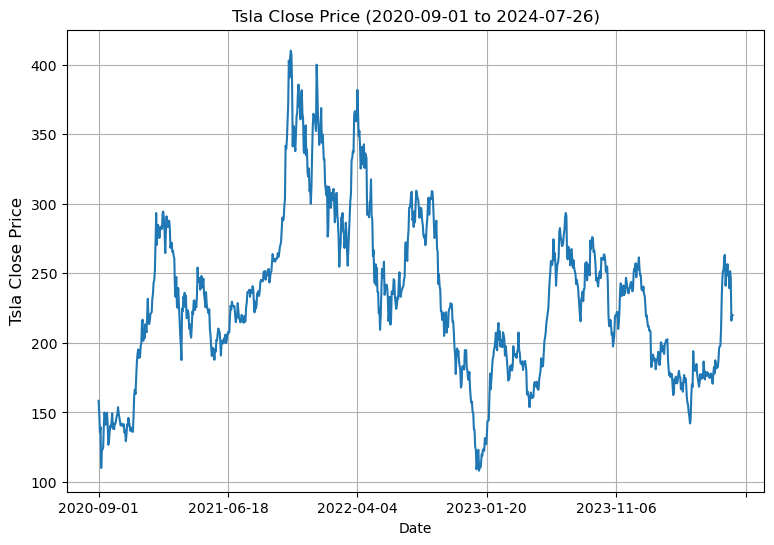

In [5]:
# (1a) plot tsla close prices
plt.figure(figsize=(9, 6))
tsla['Adj Close'].plot()
plt.title('Tsla Close Price (2020-09-01 to 2024-07-26)')
plt.ylabel('Tsla Close Price', fontsize=12)
plt.grid()

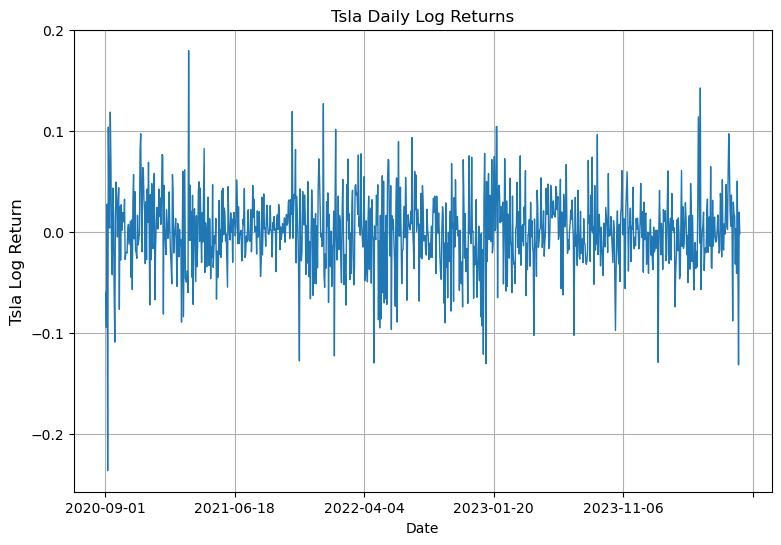

In [6]:
# (1a) log returns of tsla 
r = log(tsla['Adj Close']).diff()
plt.figure(figsize=(9, 6))
r.plot(lw=1)
plt.title('Tsla Daily Log Returns')
plt.ylabel('Tsla Log Return', fontsize=12)
plt.grid()

In [7]:
#(1b)
# Volatilites python class from lecture  
class Volatilities:
    def __init__(self, OHLC, n=15, N=252):
        self.n = n
        self.N = N
        self.OHLC = pd.DataFrame(OHLC)
        self.o = self.OHLC.Open
        self.h = self.OHLC.High
        self.l = self.OHLC.Low
        self.c = self.OHLC.Close
        self.r = log(self.OHLC['Close']).diff()
        self.vols_c = [np.nan for i in range(self.n)] 
        self.vols_p = [np.nan for i in range(self.n)]
        self.vols_gk = [np.nan for i in range(self.n)] 
        self.vols_rs = [np.nan for i in range(self.n)] 
        
        for i in range(len(self.r) - self.n):
            self.vols_c += [self.r.iloc[i:(i+self.n)].std()*sqrt(self.N)]
            self.vols_p += [self.cal_vol_p(self.h.iloc[i:(i+self.n)], self.l.iloc[i:(i+self.n)])*sqrt(self.N)]
            self.vols_gk += [self.cal_vol_gk(self.o.iloc[i:(i+self.n)], self.h.iloc[i:(i+self.n)], self.l.iloc[i:(i+self.n)], self.c.iloc[i:(i+self.n)])*sqrt(self.N)]
            self.vols_rs += [self.cal_vol_rs(self.o.iloc[i:(i+self.n)], self.h.iloc[i:(i+self.n)], self.l.iloc[i:(i+self.n)], self.c.iloc[i:(i+self.n)])*sqrt(self.N)]
        self.vols = pd.DataFrame({'close': self.vols_c, 'parkinson': self.vols_p, 'garman-klass': self.vols_gk, 'rogers-satchell': self.vols_rs})
        self.vols.index = self.OHLC.index
        
    def cal_vol_p(self, H, L):
        return np.sqrt(((log(H) - log(L))**2).mean()/log(2)/4)
    
    def cal_vol_gk(self, O, H, L, C):
        term1 = ((log(O) - log(L))**2).mean()/2
        term2 = (2*log(2) - 1)*((log(C) - log(O))**2).mean()
        return np.sqrt(term1 + term2)
    
    def cal_vol_rs(self, O, H, L, C):
        u, d, c = log(H) - log(O), log(L) - log(O), log(C) - log(O)
        return np.sqrt((u*(u-c)).mean() + (d*(d-c)).mean())

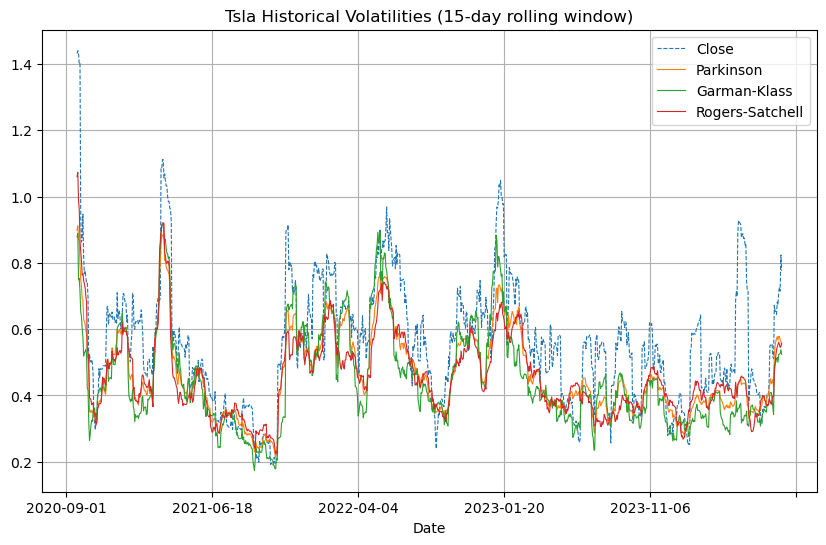

In [8]:
# (1b) continued
# calculate volatilities using historical data

tsla_vols = Volatilities(tsla, n=15, N=252)
vols = tsla_vols.vols

plt.figure(figsize=(10, 6))
vols['close'].plot(ls='--', label='Close', lw=0.8)
vols['parkinson'].plot(lw=0.8, label='Parkinson')
vols['garman-klass'].plot(lw=0.8, label='Garman-Klass')
vols['rogers-satchell'].plot(lw=0.8, label='Rogers-Satchell')
plt.legend()
plt.title('Tsla Historical Volatilities (15-day rolling window)')
plt.grid()
plt.show()

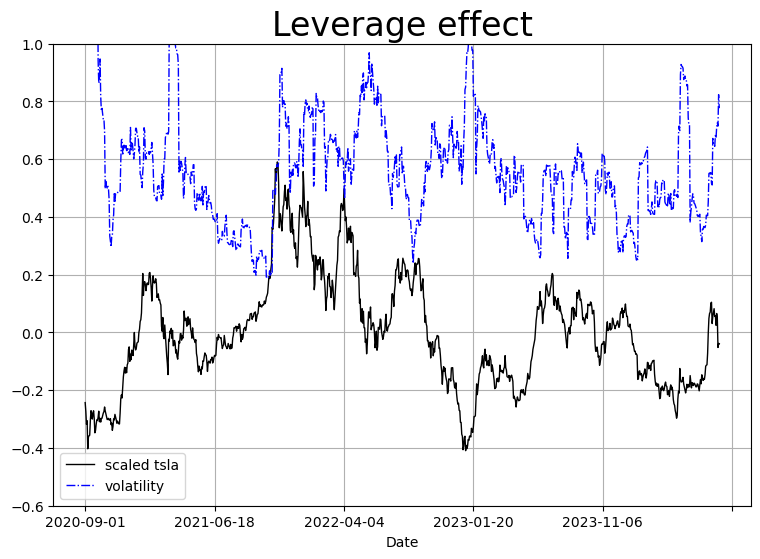

In [9]:
# (1c)
# leverage effect
tsla_scaled = (tsla - tsla.mean()) / (tsla.max() - tsla.min())
plt.figure(figsize=(9, 6))
tsla_scaled['Adj Close'].plot(color='k', lw=1, label='scaled tsla')
plt.ylim([-0.6, 1])
plt.plot(vols['close'], 'b-.', lw=1, label='volatility')
plt.grid()
plt.title('Leverage effect', fontsize=24)
plt.legend()
plt.show()

对于杠杆效应（leverage effect）的说明：

$\quad$ 从图中可以观察到，当tsla股价出现大幅下跌时（例如2022年下半年），其历史波动率（close-based volatility）显著攀升；反之，当股价企稳或回升时，波动率往往回落。这种股价与波动率之间的负相关关系，即为杠杆效应（leverage effect）。

$\quad$ 其背后的逻辑是：当公司股价下跌时，公司的权益价值下降，财务杠杆（债务/权益比）被动上升，使得股票收益对市场信息的敏感度增加，从而推高了未来的波动率预期和实际波动率。这种现象在个股中尤为常见，是金融市场中风险与收益不对称的一种典型表现。

## Implied volatility and VIX calculation

In [10]:
# load the saved data, previously downloaded from yahoo finance
aapl_calls = pd.read_csv('aapl_call_07252022.csv')
aapl_puts = pd.read_csv('aapl_put_07252022.csv')
today, expiry = '2022-07-25', '2022-08-26' 

In [11]:
# a look at the first few rows of the data
aapl_calls.head()

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney
0,AAPL220826C00070000,2022-07-21 15:28:15,70.0,83.60,83.05,83.20,0.0,0.0,6.0,2,1.074223,True
1,AAPL220826C00105000,2022-07-20 16:14:10,105.0,48.69,48.10,48.25,0.0,0.0,10.0,6,0.588871,True
2,AAPL220826C00110000,2022-07-20 17:09:38,110.0,42.77,43.20,43.35,0.0,0.0,20.0,21,0.572270,True
3,AAPL220826C00120000,2022-07-22 19:24:02,120.0,34.81,33.40,33.55,0.0,0.0,11.0,18,0.512212,True
4,AAPL220826C00125000,2022-07-22 18:50:21,125.0,29.50,28.45,28.75,0.0,0.0,1.0,34,0.477056,True


In [12]:
# a look at the last few rows of the data
aapl_puts.tail()

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney
36,AAPL220826P00170000,2022-07-22 17:45:40,170.0,16.75,17.45,17.60,0.0,0.0,3.0,16,0.274665,True
37,AAPL220826P00180000,2022-07-19 19:40:09,180.0,29.35,26.95,27.15,0.0,0.0,1000.0,150,0.293952,True
38,AAPL220826P00185000,2022-07-15 16:30:49,185.0,36.25,32.05,32.10,0.0,0.0,1.0,2,0.317390,True
39,AAPL220826P00190000,2022-07-21 18:24:42,190.0,34.75,36.90,37.10,0.0,0.0,520.0,402,0.354499,True
40,AAPL220826P00250000,2022-07-22 17:35:11,250.0,96.40,96.95,97.20,0.0,0.0,1.0,1,0.686527,True


### 2. (20pts)

Use the codes provided in lecture, especially the part on implied volatility, to 
- a) determine if there exist arbitrage opportunities in this dataset, explain your answer;
- b) calculate the implied volatilities for AAPL using option data stored in `aapl_call_07252022.csv` and `aapl_put_07252022.csv`;
- c) plot the implied volatilities versus logmoneyness; 
- d) use this dataset and the VIX formula to calculate the volatility index for AAPL.

### <font color=blue>Solution 2.</font>

d:\作业\量化金融专题\作业4\NSDHW04_Summer2026\option_analytics.py:104: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  s_adj, pv = result.params[0], -result.params[1]


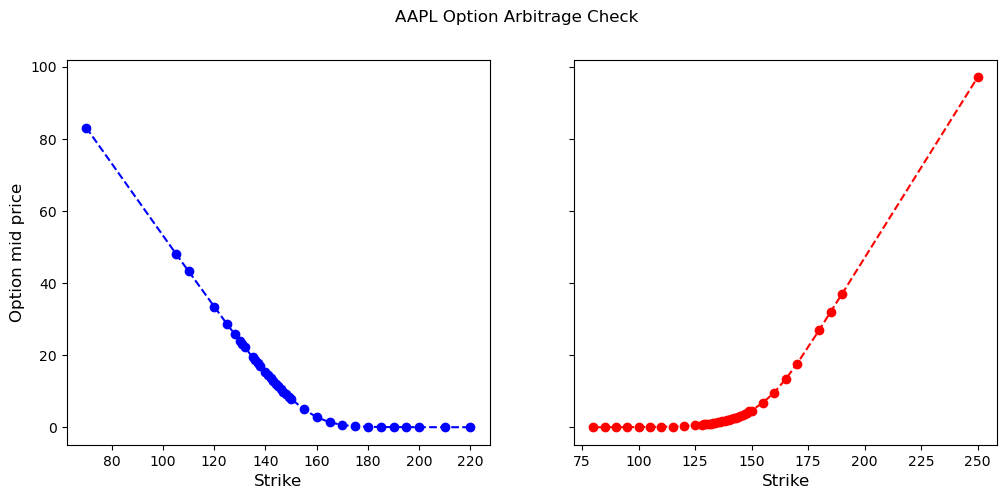

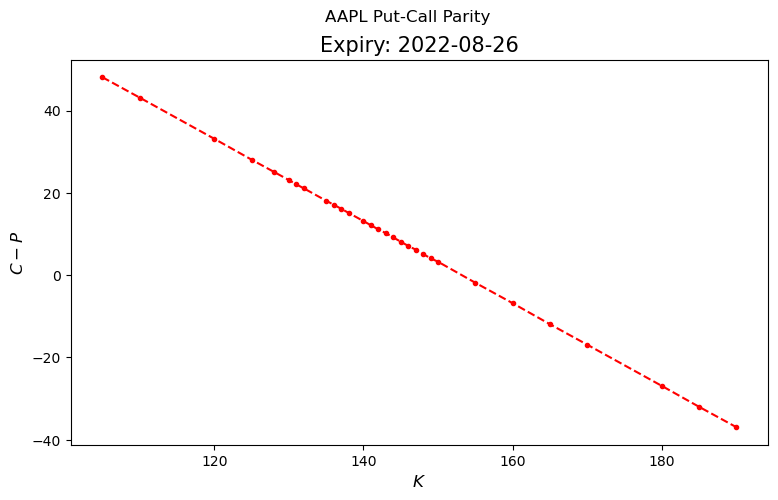

In [ ]:
#(2a)

# Check for arbitrage opportunities using OptionAnalytics class
aapl_opt = OptionAnalytics([aapl_calls, aapl_puts], expiry, today)

# Plot option prices vs strike to check monotonicity and convexity
aapl_opt.plot_arb()
plt.suptitle('AAPL Option Arbitrage Check')
plt.show()

# Plot put-call parity
aapl_opt.plot_parity()
plt.suptitle('AAPL Put-Call Parity')
plt.show()

（2a）套利机会检查

从上述图表可以得出以下结论：

1. 单调性检查（Monotonicity）

从上图（plot_arb()）可以看出：

看涨期权（左图）：期权价格随着行权价的增加而递减，整体呈现单调下降趋势，没有出现价格上涨的反常情况。没有违反单调性要求。

看跌期权（右图）：期权价格随着行权价的增加而递增，整体呈现单调上升趋势，没有出现价格下降的反常情况。没有违反单调性要求。

如果出现更高行权价的看涨期权比更低行权价的看涨期权更贵，或者更低行权价的看跌期权比更高行权价的看跌期权更贵，套利者就可以通过买入便宜的期权、卖出贵的期权来获取无风险利润。本数据集中没有观察到此类现象。

2. 凸性检查（Convexity）

两个图中的期权价格曲线均呈现平滑凸性。期权价格应该是行权价的凸函数。如果出现凹形区域，则存在蝶式套利机会（买入两端的期权，卖出中间的两个期权）。图中没有明显凹形，说明不存在凸性套利机会。

3. 看跌-看涨平价检查（Put-Call Parity）

从 plot_parity() 图可以看出：

看跌-看涨平价关系为：
$$
C-P=S-K\cdot e^{-rT}
$$

图中散点基本落在一条直线上，没有出现明显偏离，说明市场价格与无套利理论基本一致。

回归拟合良好，进一步的数据显示：

斜率 = -1.000000（理论值为 -1），偏差基本可以忽略；

截距 = 153.1908，即为回归法估计的无套利理论现货价格，与前文 PCP 调整后的现货价格（153.19）高度一致。

R² = 0.99999370，拟合优度极高，表明线性关系解释了超过 99.999% 的数据变异；

RMSE = 0.0488 美元，远小于期权最小报价单位（0.01 美元），即使存在微小定价偏差，也无法覆盖交易成本，因此不存在可执行的套利机会。

说明不存在明显的平价套利机会。

结论：

基于单调性、凸性和看跌-看涨平价三项检查，AAPL期权数据集中没有发现显著套利机会。

In [14]:
#(2b)
# Compute implied volatilities
ivs = aapl_opt.ivs
ks = aapl_opt.ks
s_adj = aapl_opt.s_adj

print(f"Adjusted spot price from put-call parity: {s_adj:.2f}")
print(f"Number of implied volatilities: {len(ivs)}")

# Print the implied volatilities
print("\nImplied volatilities for AAPL options (Strike vs IV):")
for k, iv in zip(ks, ivs):
    print(f"Strike: {k:7.2f}   Implied Vol: {iv:.4f}")

Adjusted spot price from put-call parity: 153.19
Number of implied volatilities: 30

Implied volatilities for AAPL options (Strike vs IV):
Strike:  105.00   Implied Vol: 0.5083
Strike:  110.00   Implied Vol: 0.5365
Strike:  120.00   Implied Vol: 0.4815
Strike:  125.00   Implied Vol: 0.4420
Strike:  128.00   Implied Vol: 0.4350
Strike:  130.00   Implied Vol: 0.4275
Strike:  131.00   Implied Vol: 0.4191
Strike:  132.00   Implied Vol: 0.4195
Strike:  135.00   Implied Vol: 0.4048
Strike:  136.00   Implied Vol: 0.4031
Strike:  137.00   Implied Vol: 0.4024
Strike:  138.00   Implied Vol: 0.3982
Strike:  140.00   Implied Vol: 0.3888
Strike:  141.00   Implied Vol: 0.3835
Strike:  142.00   Implied Vol: 0.3773
Strike:  143.00   Implied Vol: 0.3805
Strike:  144.00   Implied Vol: 0.3738
Strike:  145.00   Implied Vol: 0.3677
Strike:  146.00   Implied Vol: 0.3621
Strike:  147.00   Implied Vol: 0.3600
Strike:  148.00   Implied Vol: 0.3536
Strike:  149.00   Implied Vol: 0.3490
Strike:  150.00   Implied

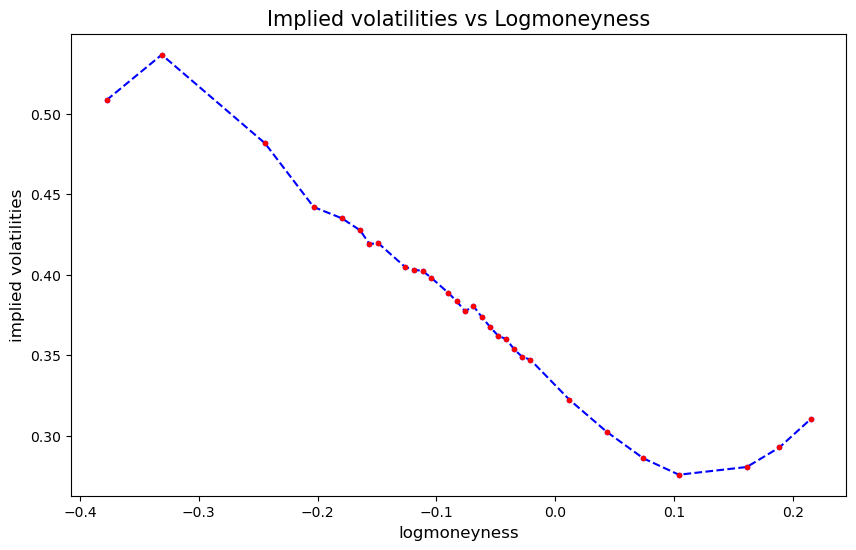

In [15]:
#(2c) plot implied vol vs logmoneyness
aapl_opt.plot_imp_vols2()
plt.show()

In [16]:
# (2d) 
# recall the VIX formula
# VIX^2 = 2/T sum_i (Delta K_i)/Ki^2 Qi(Ki) - 1/T (F/K0 - 1)^2, 
# where Q denotes prices of out-of-money options, F the forward price,  
# and K0 the largest strike smaller than F

In [18]:
# calculate VIX for AAPL

# ---------- 1. Basic parameters ----------
T = (dt.strptime(expiry, '%Y-%m-%d') - dt.strptime(today, '%Y-%m-%d')).days / 365.0
pv = aapl_opt.imp_vols()['pv']   # discount factor e^{-rT} from PCP regression

# ---------- 2. Extract option data ----------
ks_c = aapl_calls['strike'].values
ks_p = aapl_puts['strike'].values
c_mid = ((aapl_calls['bid'] + aapl_calls['ask']) / 2).values
p_mid = ((aapl_puts['bid'] + aapl_puts['ask']) / 2).values

# Use only strikes common to both calls and puts
ks = np.intersect1d(ks_c, ks_p)
c = np.array([c_mid[np.where(ks_c == k)[0][0]] for k in ks])
p = np.array([p_mid[np.where(ks_p == k)[0][0]] for k in ks])

# ---------- 3. Forward price F (CBOE method) ----------
# Find the strike with the smallest absolute call-put spread
idx = np.argmin(np.abs(c - p))
F = ks[idx] + (c[idx] - p[idx]) / pv   # correct discounting: divide by pv (= multiply by e^{rT})

# ---------- 4. K0: largest strike below F ----------
K0 = ks[ks < F][-1]

# ---------- 5. OTM option prices Q ----------
# For K < K0: use puts; for K > K0: use calls; at K0: use average
Q = np.where(ks < K0, p, np.where(ks > K0, c, (c + p) / 2))

# ---------- 6. Delta K (strike intervals) ----------
dK = np.diff(ks)
dK = np.concatenate(([dK[0]], (dK[1:] + dK[:-1]) / 2, [dK[-1]]))

# ---------- 7. VIX² and final VIX ----------
sigma2 = (2.0 / T) * np.sum(dK / ks**2 * Q) - (1.0 / T) * (F / K0 - 1.0)**2
if sigma2 < 0:
    sigma2 = 0.0
vix = 100 * np.sqrt(sigma2)   # output in percentage points

print(f"AAPL VIX (30-day implied volatility) = {vix:.2f}%")

AAPL VIX (30-day implied volatility) = 35.27%
